# **Convert detailed management info to machine-readable format**

# Info

- This notebook converts detailed managament info available for the grassland research site [Oensingen (CH-OE2)](https://www.swissfluxnet.ethz.ch/index.php/sites/site-info-ch-oe2/) to a time series format.
- Management info is collected, simplified and then grouped into the following 7 management events:
    - `MGMT_SOILCULTIVATION`
    - `MGMT_PESTICIDE_HERBICIDE`
    - `MGMT_HARVEST`
    - `MGMT_SOWING`
    - `MGMT_FERT_ORG`
    - `MGMT_FERT_MIN`
- In addition, `TIMESINCE` variables are created for all events, counting the *days* since the last occurrence of the respective event
    - Example: `TIMESINCE_MGMT_FERT_ORG` is the time in days since the last fertilization with organic fertilizer

---

# Imports

---

In [92]:
import datetime
from collections import Counter
import pandas as pd
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from diive.core.io.files import save_parquet, load_parquet
from diive.pkgs.createvar.timesince import TimeSince
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.core.plotting.timeseries import TimeSeries

---

# Read data

---

In [ ]:
file_mgmt = '../../data/MANAGEMENT/mgmt_2021-23.csv'
mgmt_detailed = pd.read_csv(file_mgmt, skiprows=1)
mgmt_detailed = mgmt_detailed.loc[:, ['Management_Category', 'Management_Subcategory', 'Management_Specific', 'DateYear', 'N kg/ha', 'Amount/ha']]
mgmt_detailed 

,Management_Category,Management_Subcategory,Management_Specific,DateYear,N kg/ha,Amount/ha
0,fertilization,manure,solid,12.01.2021,NaN,NaN
1,fertilization,mineral,Mg-Ammonsalpeter,26.02.2021,27.0,100.0
2,fertilization,manure,liquid,03.03.2021,NaN,25.0
3,harvest,mowing,harvester,30.05.2021,NaN,NaN
4,harvest,straw harvest,NaN,01.06.2021,NaN,13548.0
5,fertilization,manure,liquid,04.06.2021,NaN,25.0
6,harvest,mowing,harvester,20.07.2021,NaN,NaN
7,harvest,straw harvest,NaN,21.07.2021,NaN,8709.0
8,fertilization,manure,liquid,27.07.2021,NaN,25.0
9,harvest,mowing,harvester,02.09.2021,NaN,NaN


# Calculate N amount for organic fertilizations

Calculate tot N kg/ha for the organic fertilizations where we have to use multiplication factors to get an estimate of the applied N:
- Kg of N per hectar for liquid manure fertilizations are calculated according to 2024 values from the slurry samples taken by Francesco Argento on 02.04.2024 

*1.08 kg N per m3 of liquid manure (mean of 1.04 and 1.12)*

(Christoff Ammann measurements in 2010 indicated 1.5 kg N per m3)

- Kg of N per hectar for solid manure fertilizations are calculated according to 2010 values -> see in CH-OE2.Management.allyears.xlsx

*0.006 kg of N per kg of solid manure*

In [94]:
# Convert 'amount/ha' and 'n_kg/ha' to numeric
mgmt_detailed['Amount/ha'] = pd.to_numeric(mgmt_detailed['Amount/ha'], errors='coerce')
mgmt_detailed['N kg/ha'] = pd.to_numeric(mgmt_detailed['N kg/ha'], errors='coerce')

# Calculate the kg of N per hectar for the fertilizations
# for slurry
mgmt_detailed.loc[
    (mgmt_detailed['Management_Subcategory'] == 'manure') & 
     (mgmt_detailed['Management_Specific'] == 'liquid'), 'N kg/ha'] = mgmt_detailed['Amount/ha'] * 1.08
# for solid manure
mgmt_detailed.loc[
    (mgmt_detailed['Management_Subcategory'] == 'manure') & 
     (mgmt_detailed['Management_Specific'] == 'solid'), 'N kg/ha'] = mgmt_detailed['Amount/ha'] * 0.006

mgmt_detailed.drop(columns='Amount/ha', inplace=True)

# **MANAGEMENT EVENTS DAILY** (daily scale)

---

In [95]:
# Create Start and End variables
mgmt_detailed.rename(columns={'DateYear':'Start'},inplace=True)
mgmt_detailed['Start'] = pd.to_datetime(mgmt_detailed['Start'], format="%d.%m.%Y")
mgmt_detailed['End'] = mgmt_detailed['Start']

Remove entries for the removal of the mowed grass as it is not relevant for any analysis, the mowing is enough

In [96]:
mgmt_detailed = mgmt_detailed[mgmt_detailed['Management_Subcategory'] != 'straw harvest'].copy()

In [97]:
# Fill nan
mgmt_detailed['Management_Category'] = mgmt_detailed['Management_Category'].fillna('-9999')
mgmt_detailed['Management_Subcategory'] = mgmt_detailed['Management_Subcategory'].fillna('-9999')
mgmt_detailed['Management_Specific'] = mgmt_detailed['Management_Specific'].fillna('-9999')
mgmt_detailed['Total Fertilizer N (kg/ha)'] = mgmt_detailed['N kg/ha'].fillna(0)
mgmt_detailed.drop(columns='N kg/ha', inplace=True)
mgmt_detailed

,Management_Category,Management_Subcategory,Management_Specific,Start,End,Total Fertilizer N (kg/ha)
0,fertilization,manure,solid,2021-01-12,2021-01-12,0.0
1,fertilization,mineral,Mg-Ammonsalpeter,2021-02-26,2021-02-26,27.0
2,fertilization,manure,liquid,2021-03-03,2021-03-03,27.0
3,harvest,mowing,harvester,2021-05-30,2021-05-30,0.0
5,fertilization,manure,liquid,2021-06-04,2021-06-04,27.0
6,harvest,mowing,harvester,2021-07-20,2021-07-20,0.0
8,fertilization,manure,liquid,2021-07-27,2021-07-27,27.0
9,harvest,mowing,harvester,2021-09-02,2021-09-02,0.0
11,fertilization,manure,liquid,2021-09-09,2021-09-09,0.0
12,harvest,mowing,harvester,2021-10-18,2021-10-18,0.0


In [98]:
mgmt_detailed.count()

Management_Category           34
Management_Subcategory        34
Management_Specific           34
Start                         34
End                           34
Total Fertilizer N (kg/ha)    34
dtype: int64

In [99]:
# ## Make full timestamp for start and end dates
# - The full timestamp for start and end dates takes into account that the flux records are stored with a timestamp that shows the END of the averaging interval
# - This means that a record with timestamp `2021-06-05 00:00` contains data between `2021-06-04 23:30` (exclusive) and `2021-06-05 00:00` (inclusive)
# - To correctly assign a management to a specific day, one second needs to be added to the start date (because the time 00:00 still has data from the *previous* day)
# - For the end data to cover the full day, 24 hours need to be added and in addition one second, to include the 00:00 time of the next day
# mgmt_detailed['Start'] = pd.to_datetime(mgmt_detailed['Start']).add(datetime.timedelta(seconds=1))
# mgmt_detailed['End'] = pd.to_datetime(mgmt_detailed['End']).add(datetime.timedelta(hours=24, seconds=1))
# mgmt_detailed

</br>

## Create `MGMT_SPECIFIC` variables

In [100]:
# Add PREFIX column, use MGMT when building variable names later
mgmt_detailed['PREFIX'] = 'MGMT'

### Rename Management_Category

In [101]:
mgmt_detailed['Management_Category'] = mgmt_detailed['Management_Category'].str.replace('fertilization', 'FERT')
mgmt_detailed['Management_Category'] = mgmt_detailed['Management_Category'].str.replace('protection', 'PPGM')
mgmt_detailed['Management_Category'] = mgmt_detailed['Management_Category'].str.replace('harvest', 'USE')
mgmt_detailed['Management_Category'] = mgmt_detailed['Management_Category'].str.replace('sowing', 'SOWING')
mgmt_detailed['Management_Category'] = mgmt_detailed['Management_Category'].str.replace('cultivation', 'SOILCULTIVATION')

### Rename Management_Subcategory

In [102]:
mgmt_detailed['Management_Subcategory'] = mgmt_detailed['Management_Subcategory'].str.replace('manure', 'ORG')
mgmt_detailed['Management_Subcategory'] = mgmt_detailed['Management_Subcategory'].str.replace('mineral', 'MIN')
mgmt_detailed['Management_Subcategory'] = mgmt_detailed['Management_Subcategory'].str.replace('rolling', 'ROLLING')
mgmt_detailed['Management_Subcategory'] = mgmt_detailed['Management_Subcategory'].str.replace('mowing', 'MOWING')
mgmt_detailed['Management_Subcategory'] = mgmt_detailed['Management_Subcategory'].str.replace('grain harvest', 'HARVEST')
mgmt_detailed['Management_Subcategory'] = mgmt_detailed['Management_Subcategory'].str.replace('herbicide', 'HERBICIDE')
mgmt_detailed['Management_Subcategory'] = mgmt_detailed['Management_Subcategory'].str.replace('insecticide', 'PESTICIDE')
mgmt_detailed['Management_Subcategory'] = mgmt_detailed['Management_Subcategory'].str.replace('field_cultivator', 'TILLAGE')
mgmt_detailed['Management_Subcategory'] = mgmt_detailed['Management_Subcategory'].str.replace('mulching', 'MULCHING')
mgmt_detailed['Management_Subcategory'] = mgmt_detailed['Management_Subcategory'].str.replace('sowing', '-9999')

### Rename Management_specific

In [103]:
mgmt_detailed['Management_Specific'] = mgmt_detailed['Management_Specific'].str.replace('solid', 'MAN')
mgmt_detailed['Management_Specific'] = mgmt_detailed['Management_Specific'].str.replace('liquid', 'SLU')
mgmt_detailed['Management_Specific'] = mgmt_detailed['Management_Specific'].str.replace('Glyphosate', 'ROUNDUP')
mgmt_detailed['Management_Specific'] = mgmt_detailed['Management_Specific'].str.replace('combine harvester', 'COMBINE')
mgmt_detailed['Management_Specific'] = mgmt_detailed['Management_Specific'].str.replace('Glyphosate', 'ROUNDUP')
mgmt_detailed['Management_Specific'] = mgmt_detailed['Management_Specific'].str.replace('5 cm above ground', '5CM')
mgmt_detailed['Management_Specific'] = mgmt_detailed['Management_Specific'].str.replace('direct-seeding', 'DIRECT')
mgmt_detailed['Management_Specific'] = mgmt_detailed['Management_Specific'].str.upper()

### Assemble `MGMT_SPECIFIC`variable name

In [104]:
def create_varname(row): 
    return "_".join([
        row['PREFIX'],        
        row['Management_Category'], 
        row['Management_Subcategory'],
        str(row['Management_Specific']),
        # row['Parcel']
    ])

mgmt_detailed['MGMT_SPECIFIC'] = mgmt_detailed.apply(create_varname, axis=1)
mgmt_detailed['MGMT_SPECIFIC'] = mgmt_detailed['MGMT_SPECIFIC'].str.replace('_-9999', '')
mgmt_types = mgmt_detailed['MGMT_SPECIFIC'].unique()

In [105]:
# List of unique specific managements
print("Unique specific managements:")
[print(f"{ix + 1}: {v}") for ix, v in enumerate(mgmt_types)];

Unique specific managements:
1: MGMT_FERT_ORG_MAN
2: MGMT_FERT_MIN_MG-AMMONSALPETER
3: MGMT_FERT_ORG_SLU
4: MGMT_USE_MOWING_HARVESTER
5: MGMT_PPGM_HERBICIDE_ROUNDUP
6: MGMT_SOWING_DIRECT
7: MGMT_PPGM_PESTICIDE
8: MGMT_PPGM_HERBICIDE_SPRINTER
9: MGMT_PPGM_HERBICIDE_NETZMITTEL
10: MGMT_PPGM_HERBICIDE_PIXXARO
11: MGMT_USE_HARVEST_COMBINE
12: MGMT_SOILCULTIVATION_TILLAGE
13: MGMT_SOWING
14: MGMT_FERT_MULCHING_5CM
15: MGMT_USE_MULCHING_5CM
16: MGMT_SOWING_ROLLING


In [106]:
mgmt_detailed

,Management_Category,Management_Subcategory,Management_Specific,Start,End,Total Fertilizer N (kg/ha),PREFIX,MGMT_SPECIFIC
0,FERT,ORG,MAN,2021-01-12,2021-01-12,0.0,MGMT,MGMT_FERT_ORG_MAN
1,FERT,MIN,MG-AMMONSALPETER,2021-02-26,2021-02-26,27.0,MGMT,MGMT_FERT_MIN_MG-AMMONSALPETER
2,FERT,ORG,SLU,2021-03-03,2021-03-03,27.0,MGMT,MGMT_FERT_ORG_SLU
3,USE,MOWING,HARVESTER,2021-05-30,2021-05-30,0.0,MGMT,MGMT_USE_MOWING_HARVESTER
5,FERT,ORG,SLU,2021-06-04,2021-06-04,27.0,MGMT,MGMT_FERT_ORG_SLU
6,USE,MOWING,HARVESTER,2021-07-20,2021-07-20,0.0,MGMT,MGMT_USE_MOWING_HARVESTER
8,FERT,ORG,SLU,2021-07-27,2021-07-27,27.0,MGMT,MGMT_FERT_ORG_SLU
9,USE,MOWING,HARVESTER,2021-09-02,2021-09-02,0.0,MGMT,MGMT_USE_MOWING_HARVESTER
11,FERT,ORG,SLU,2021-09-09,2021-09-09,0.0,MGMT,MGMT_FERT_ORG_SLU
12,USE,MOWING,HARVESTER,2021-10-18,2021-10-18,0.0,MGMT,MGMT_USE_MOWING_HARVESTER


### Counts of `MGMT_SPECIFIC`

In [107]:
counts = Counter(mgmt_detailed['MGMT_SPECIFIC'])
counts_df = pd.DataFrame.from_dict(counts, orient='index').reset_index()
rename_dict = {'index': 'MGMT_SPECIFIC', 0: 'COUNTS'}
counts_df = counts_df.rename(columns=rename_dict, inplace=False)
counts_df = counts_df.sort_values(by='COUNTS', ascending=False)
counts_df.to_csv("21.1_mgmt_specific_counts.csv", index=False)
counts_df

,MGMT_SPECIFIC,COUNTS
3,MGMT_USE_MOWING_HARVESTER,8
2,MGMT_FERT_ORG_SLU,7
1,MGMT_FERT_MIN_MG-AMMONSALPETER,3
0,MGMT_FERT_ORG_MAN,2
12,MGMT_SOWING,2
11,MGMT_SOILCULTIVATION_TILLAGE,2
4,MGMT_PPGM_HERBICIDE_ROUNDUP,1
5,MGMT_SOWING_DIRECT,1
7,MGMT_PPGM_HERBICIDE_SPRINTER,1
6,MGMT_PPGM_PESTICIDE,1


## Simplify and group `MGMT` variables
Group variables into 6 general categories:
- MGMT_HARVEST, MGMT_SOWING, MGMT_SOILCULTIVATION, MGMT_PESTICIDE_HERBICIDE, MGMT_FERT_ORG, MGMT_FERT_MIN

**Mulching is treated as organic fertilization and the N amount (40.2 Kg/ha) was calculated from the agb sampling on 05.09.2023 (not perfect because 20 days before the mulching took place)**

In [108]:
mgmt_detailed['MGMT'] = ''

def rename(startswith, replacewith):
    
    locs = mgmt_detailed['MGMT_SPECIFIC'].str.startswith(startswith)

    mgmt_detailed.loc[locs, 'MGMT'] = replacewith
    display(mgmt_detailed[locs].head(1))   
    print(f"Records: {len(mgmt_detailed[locs])}")

rename(startswith="MGMT_USE_HARVEST", replacewith="MGMT_HARVEST")
rename(startswith="MGMT_USE_MOWING", replacewith="MGMT_HARVEST")
rename(startswith="MGMT_USE_MULCHING", replacewith="MGMT_HARVEST")

rename(startswith="MGMT_SOWING", replacewith="MGMT_SOWING")

rename(startswith="MGMT_SOILCULTIVATION", replacewith="MGMT_SOILCULTIVATION")
rename(startswith="MGMT_SOWING_ROLLING", replacewith="MGMT_SOILCULTIVATION")

rename(startswith="MGMT_PPGM_PESTICIDE", replacewith="MGMT_PESTICIDE_HERBICIDE")
rename(startswith="MGMT_PPGM_HERBICIDE", replacewith="MGMT_PESTICIDE_HERBICIDE")

rename(startswith="MGMT_FERT_ORG", replacewith="MGMT_FERT_ORG")
rename(startswith="MGMT_FERT_MULCHING", replacewith="MGMT_FERT_ORG")
rename(startswith="MGMT_FERT_MIN", replacewith="MGMT_FERT_MIN")

,Management_Category,Management_Subcategory,Management_Specific,Start,End,Total Fertilizer N (kg/ha),PREFIX,MGMT_SPECIFIC,MGMT
34,USE,HARVEST,COMBINE,2023-07-15,2023-07-15,0.0,MGMT,MGMT_USE_HARVEST_COMBINE,MGMT_HARVEST


Records: 1


,Management_Category,Management_Subcategory,Management_Specific,Start,End,Total Fertilizer N (kg/ha),PREFIX,MGMT_SPECIFIC,MGMT
3,USE,MOWING,HARVESTER,2021-05-30,2021-05-30,0.0,MGMT,MGMT_USE_MOWING_HARVESTER,MGMT_HARVEST


Records: 8


,Management_Category,Management_Subcategory,Management_Specific,Start,End,Total Fertilizer N (kg/ha),PREFIX,MGMT_SPECIFIC,MGMT
39,USE,MULCHING,5CM,2023-09-25,2023-09-25,0.0,MGMT,MGMT_USE_MULCHING_5CM,MGMT_HARVEST


...

Records: 9


,Management_Category,Management_Subcategory,Management_Specific,Start,End,Total Fertilizer N (kg/ha),PREFIX,MGMT_SPECIFIC,MGMT
38,FERT,MULCHING,5CM,2023-09-25,2023-09-25,40.2,MGMT,MGMT_FERT_MULCHING_5CM,MGMT_FERT_ORG


Records: 1


,Management_Category,Management_Subcategory,Management_Specific,Start,End,Total Fertilizer N (kg/ha),PREFIX,MGMT_SPECIFIC,MGMT
1,FERT,MIN,MG-AMMONSALPETER,2021-02-26,2021-02-26,27.0,MGMT,MGMT_FERT_MIN_MG-AMMONSALPETER,MGMT_FERT_MIN


Records: 3


In [109]:
mgmt_detailed

,Management_Category,Management_Subcategory,Management_Specific,Start,End,Total Fertilizer N (kg/ha),PREFIX,MGMT_SPECIFIC,MGMT
0,FERT,ORG,MAN,2021-01-12,2021-01-12,0.0,MGMT,MGMT_FERT_ORG_MAN,MGMT_FERT_ORG
1,FERT,MIN,MG-AMMONSALPETER,2021-02-26,2021-02-26,27.0,MGMT,MGMT_FERT_MIN_MG-AMMONSALPETER,MGMT_FERT_MIN
2,FERT,ORG,SLU,2021-03-03,2021-03-03,27.0,MGMT,MGMT_FERT_ORG_SLU,MGMT_FERT_ORG
3,USE,MOWING,HARVESTER,2021-05-30,2021-05-30,0.0,MGMT,MGMT_USE_MOWING_HARVESTER,MGMT_HARVEST
5,FERT,ORG,SLU,2021-06-04,2021-06-04,27.0,MGMT,MGMT_FERT_ORG_SLU,MGMT_FERT_ORG
6,USE,MOWING,HARVESTER,2021-07-20,2021-07-20,0.0,MGMT,MGMT_USE_MOWING_HARVESTER,MGMT_HARVEST
8,FERT,ORG,SLU,2021-07-27,2021-07-27,27.0,MGMT,MGMT_FERT_ORG_SLU,MGMT_FERT_ORG
9,USE,MOWING,HARVESTER,2021-09-02,2021-09-02,0.0,MGMT,MGMT_USE_MOWING_HARVESTER,MGMT_HARVEST
11,FERT,ORG,SLU,2021-09-09,2021-09-09,0.0,MGMT,MGMT_FERT_ORG_SLU,MGMT_FERT_ORG
12,USE,MOWING,HARVESTER,2021-10-18,2021-10-18,0.0,MGMT,MGMT_USE_MOWING_HARVESTER,MGMT_HARVEST


In [110]:
mgmt_detailed.to_csv("21.2_mgmt_detailed.csv")

In [111]:
print("Check for missing management info:")
mgmt_detailed.isnull().sum()

Check for missing management info:


Management_Category           0
Management_Subcategory        0
Management_Specific           0
Start                         0
End                           0
Total Fertilizer N (kg/ha)    0
PREFIX                        0
MGMT_SPECIFIC                 0
MGMT                          0
dtype: int64

## Collect management info in daily dataframe

### Create daily timestamp, starting with year of first management event in 2021

In [112]:
timestamp_daily = pd.date_range("2021-01-01", "2023-12-31", freq='d')
timestamp_daily

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08', '2021-01-09', '2021-01-10',
               ...
               '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29', '2023-12-30', '2023-12-31'], dtype='datetime64[ns]', length=1095, freq='D')

In [113]:
# ## Create full timestamp, starting with year of first management event in 2021
# timestamp_full = pd.date_range("2021-01-01 00:15:00", "2023-01-01 23:45:00", freq='30min')
# timestamp_full

### Create empty dataframe

In [114]:
cols = np.unique(mgmt_detailed['MGMT']).tolist()
mgmt_daily = pd.DataFrame(index=timestamp_daily, columns=cols)
mgmt_daily.index

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08', '2021-01-09', '2021-01-10',
               ...
               '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29', '2023-12-30', '2023-12-31'], dtype='datetime64[ns]', length=1095, freq='D')

### Insert management info into management dataframe with daily timestamp

In [115]:
for ix, event in mgmt_detailed.iterrows():
    varname = event['MGMT']
    start = event['Start']
    end = event['End']
    print(f"from {start} to {end}: {varname}")
    locs = (mgmt_daily.index >= start) & (mgmt_daily.index <= end)    
    mgmt_daily.loc[locs, varname] = 1    

mgmt_daily = mgmt_daily.fillna(0)

from 2021-01-12 00:00:00 to 2021-01-12 00:00:00: MGMT_FERT_ORG
from 2021-02-26 00:00:00 to 2021-02-26 00:00:00: MGMT_FERT_MIN
from 2021-03-03 00:00:00 to 2021-03-03 00:00:00: MGMT_FERT_ORG
from 2021-05-30 00:00:00 to 2021-05-30 00:00:00: MGMT_HARVEST
from 2021-06-04 00:00:00 to 2021-06-04 00:00:00: MGMT_FERT_ORG
from 2021-07-20 00:00:00 to 2021-07-20 00:00:00: MGMT_HARVEST
from 2021-07-27 00:00:00 to 2021-07-27 00:00:00: MGMT_FERT_ORG
from 2021-09-02 00:00:00 to 2021-09-02 00:00:00: MGMT_HARVEST
from 2021-09-09 00:00:00 to 2021-09-09 00:00:00: MGMT_FERT_ORG
from 2021-10-18 00:00:00 to 2021-10-18 00:00:00: MGMT_HARVEST
from 2022-01-14 00:00:00 to 2022-01-14 00:00:00: MGMT_FERT_ORG
from 2022-03-08 00:00:00 to 2022-03-08 00:00:00: MGMT_FERT_ORG
from 2022-03-10 00:00:00 to 2022-03-10 00:00:00: MGMT_FERT_ORG
from 2022-05-14 00:00:00 to 2022-05-14 00:00:00: MGMT_HARVEST
from 2022-06-25 00:00:00 to 2022-06-25 00:00:00: MGMT_HARVEST
from 2022-08-08 00:00:00 to 2022-08-08 00:00:00: MGMT_HARVEST

C:\Users\turcof\AppData\Local\Temp\ipykernel_24396\1418467741.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mgmt_daily = mgmt_daily.fillna(0)


In [116]:
mgmt_daily = mgmt_daily.reindex(sorted(mgmt_daily.columns), axis=1)

In [117]:
mgmt_daily

,MGMT_FERT_MIN,MGMT_FERT_ORG,MGMT_HARVEST,MGMT_PESTICIDE_HERBICIDE,MGMT_SOILCULTIVATION,MGMT_SOWING
2021-01-01,0,0,0,0,0,0
2021-01-02,0,0,0,0,0,0
2021-01-03,0,0,0,0,0,0
2021-01-04,0,0,0,0,0,0
2021-01-05,0,0,0,0,0,0
2021-01-06,0,0,0,0,0,0
2021-01-07,0,0,0,0,0,0
2021-01-08,0,0,0,0,0,0
2021-01-09,0,0,0,0,0,0
2021-01-10,0,0,0,0,0,0


In [118]:
mgmt_daily.columns

Index(['MGMT_FERT_MIN', 'MGMT_FERT_ORG', 'MGMT_HARVEST', 'MGMT_PESTICIDE_HERBICIDE', 'MGMT_SOILCULTIVATION', 'MGMT_SOWING'], dtype='object')

### Plots

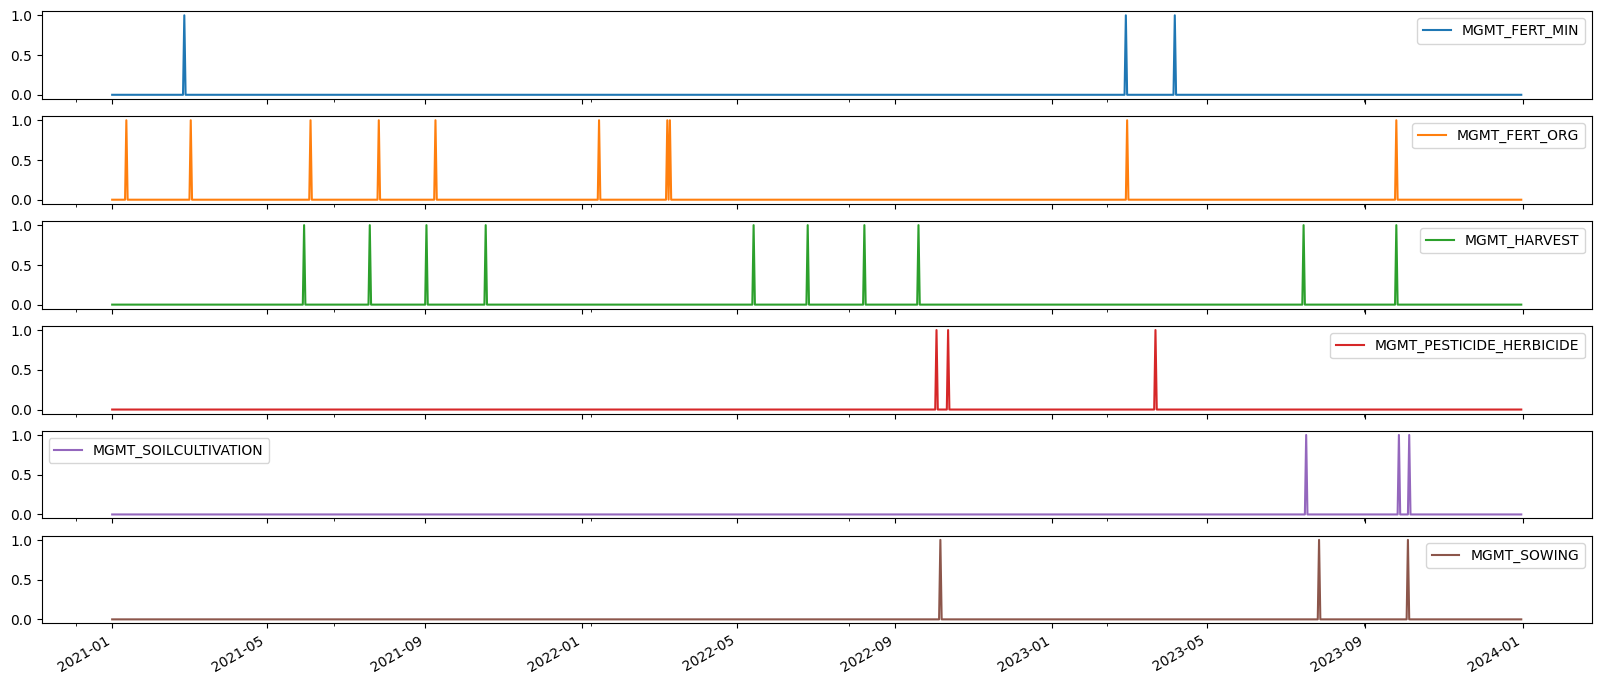

In [119]:
mgmt_daily.plot(x_compat=True, subplots=True, figsize=(20, 9));

## Calculate `TIMESINCE` management event

In [120]:
timesincedf = pd.DataFrame()

for v in mgmt_daily.columns:
    series = mgmt_daily[v].squeeze()    
    ts = TimeSince(series, lower_lim=1, include_lim=True)
    ts.calc()
    # ts_full_results = ts.get_full_results()
    timesince = ts.get_timesince()
    timesincedf[timesince.name] = timesince

In [121]:
timesincedf

,TIMESINCE_MGMT_FERT_MIN,TIMESINCE_MGMT_FERT_ORG,TIMESINCE_MGMT_HARVEST,TIMESINCE_MGMT_PESTICIDE_HERBICIDE,TIMESINCE_MGMT_SOILCULTIVATION,TIMESINCE_MGMT_SOWING
2021-01-01,1,1,1,1,1,1
2021-01-02,2,2,2,2,2,2
2021-01-03,3,3,3,3,3,3
2021-01-04,4,4,4,4,4,4
2021-01-05,5,5,5,5,5,5
2021-01-06,6,6,6,6,6,6
2021-01-07,7,7,7,7,7,7
2021-01-08,8,8,8,8,8,8
2021-01-09,9,9,9,9,9,9
2021-01-10,10,10,10,10,10,10


### Plots

c:\Users\turcof\.conda\envs\renewal\lib\site-packages\IPython\core\events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
c:\Users\turcof\.conda\envs\renewal\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


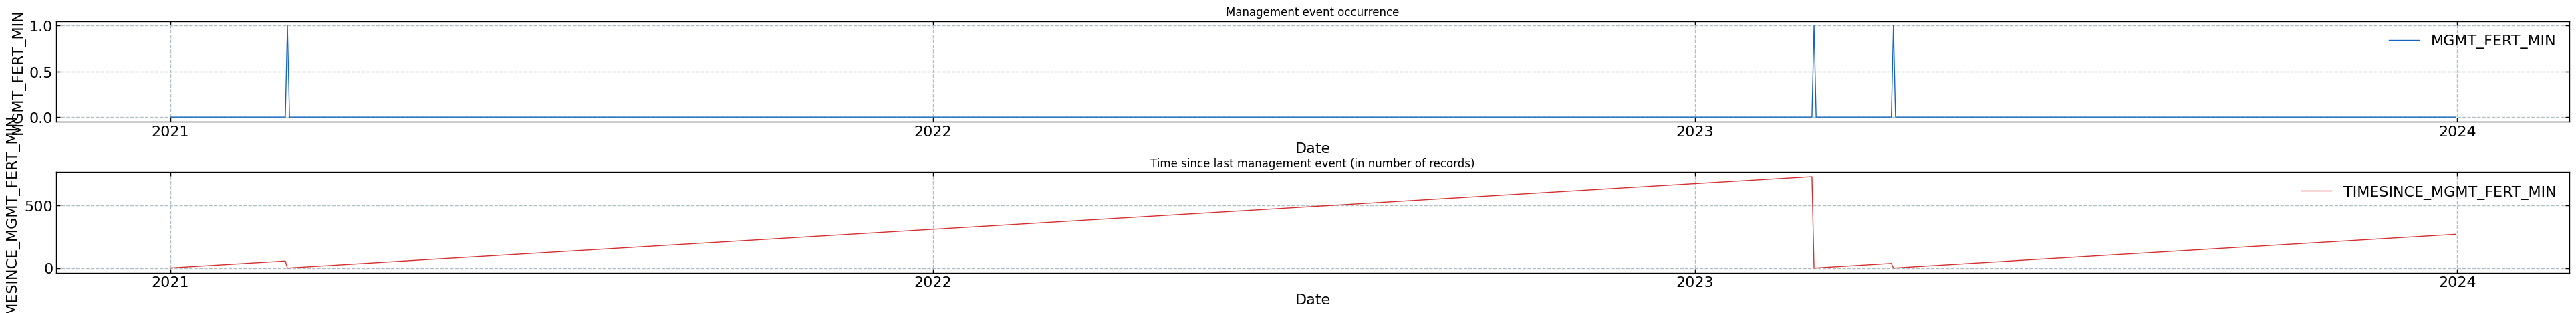

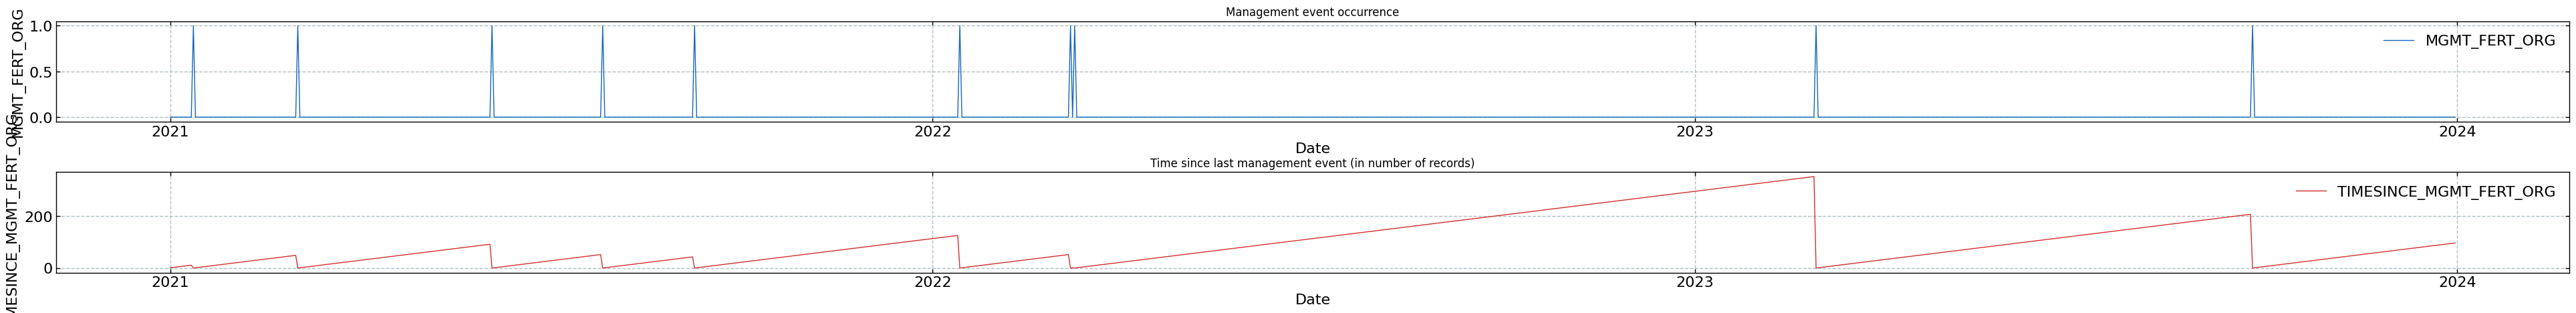

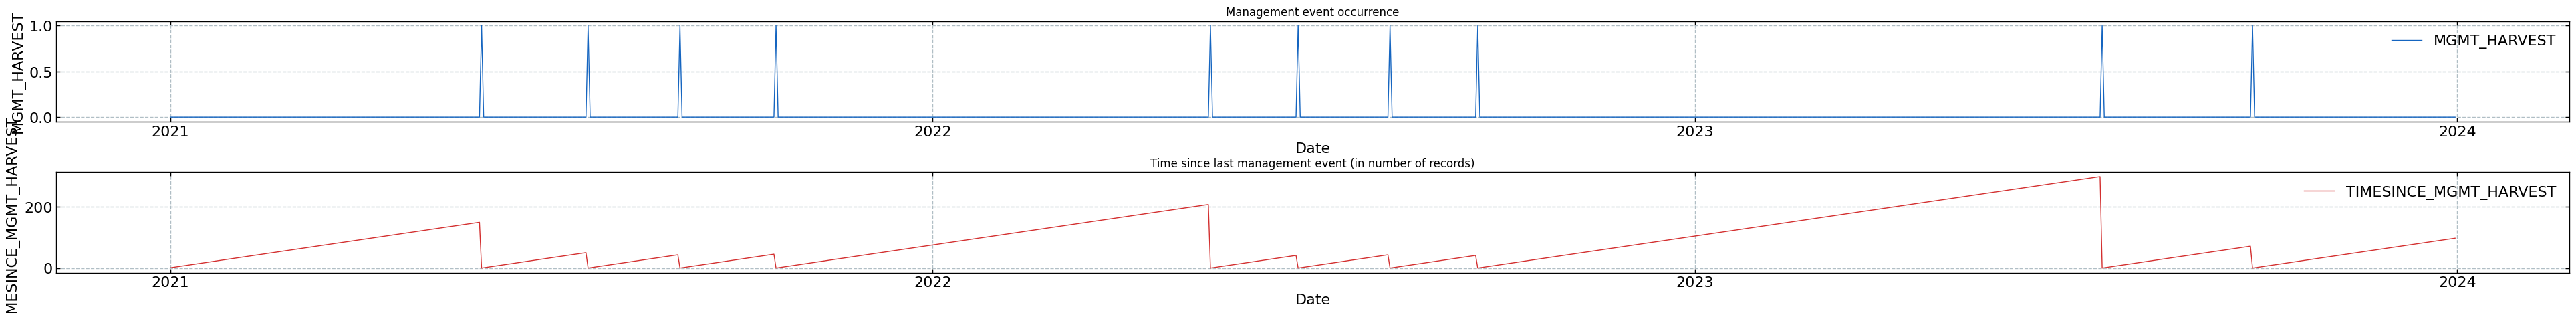

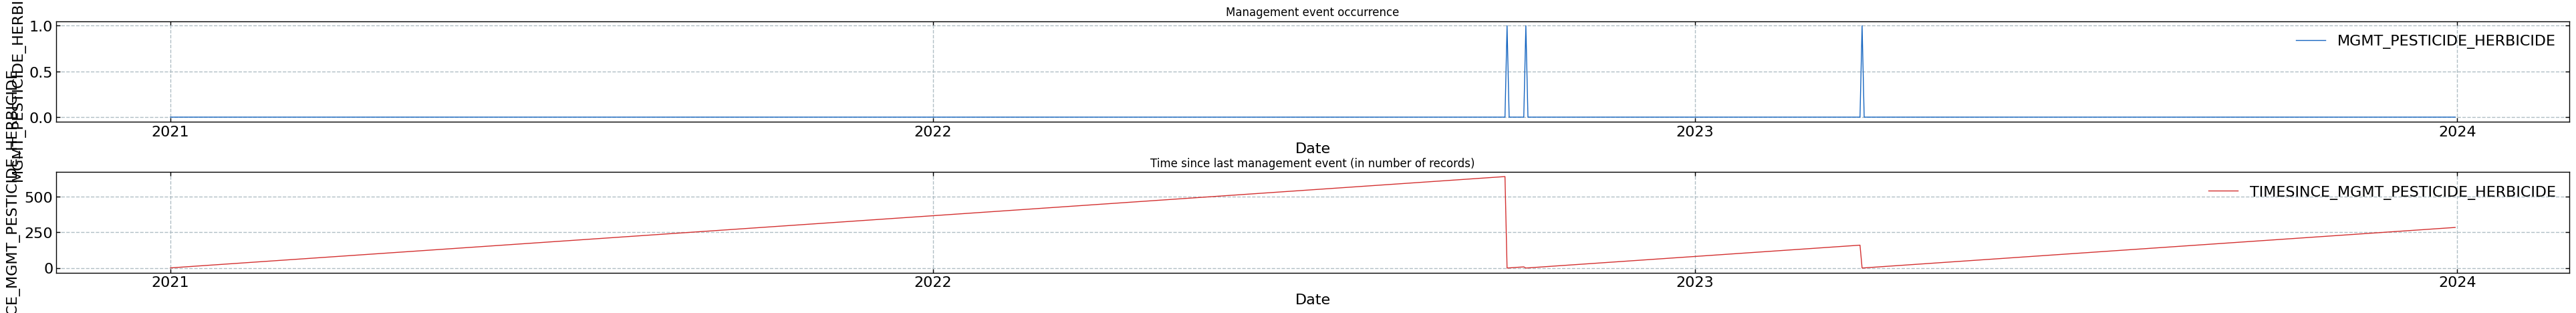

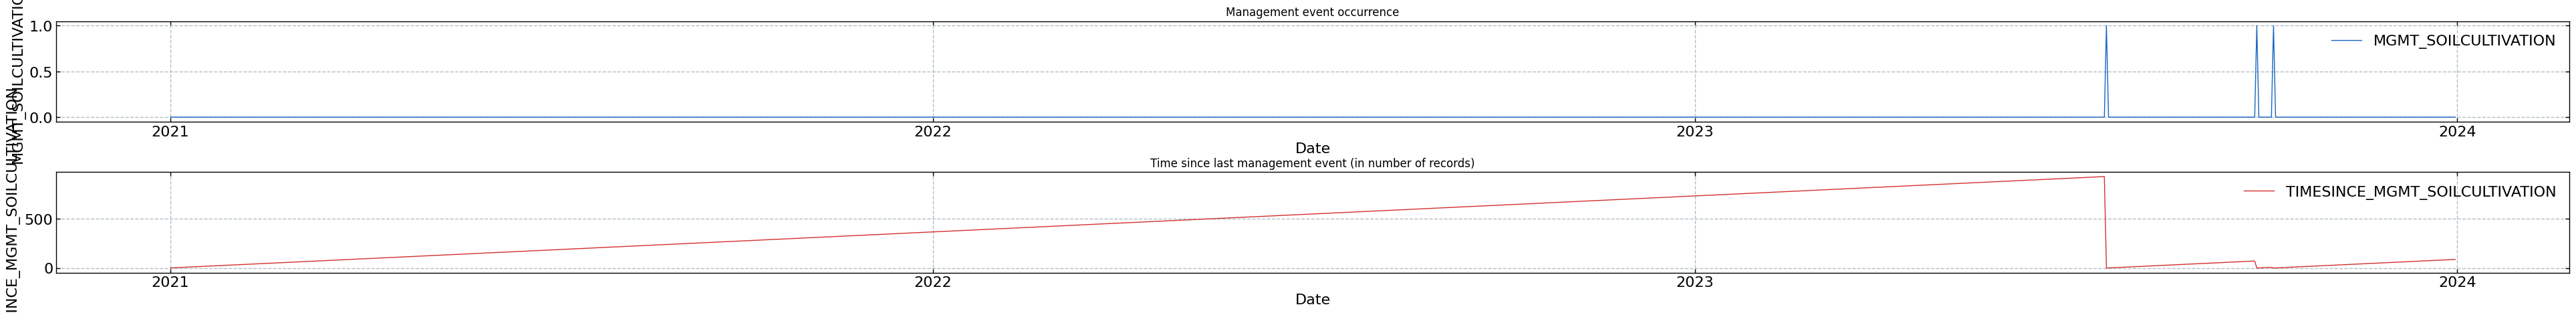

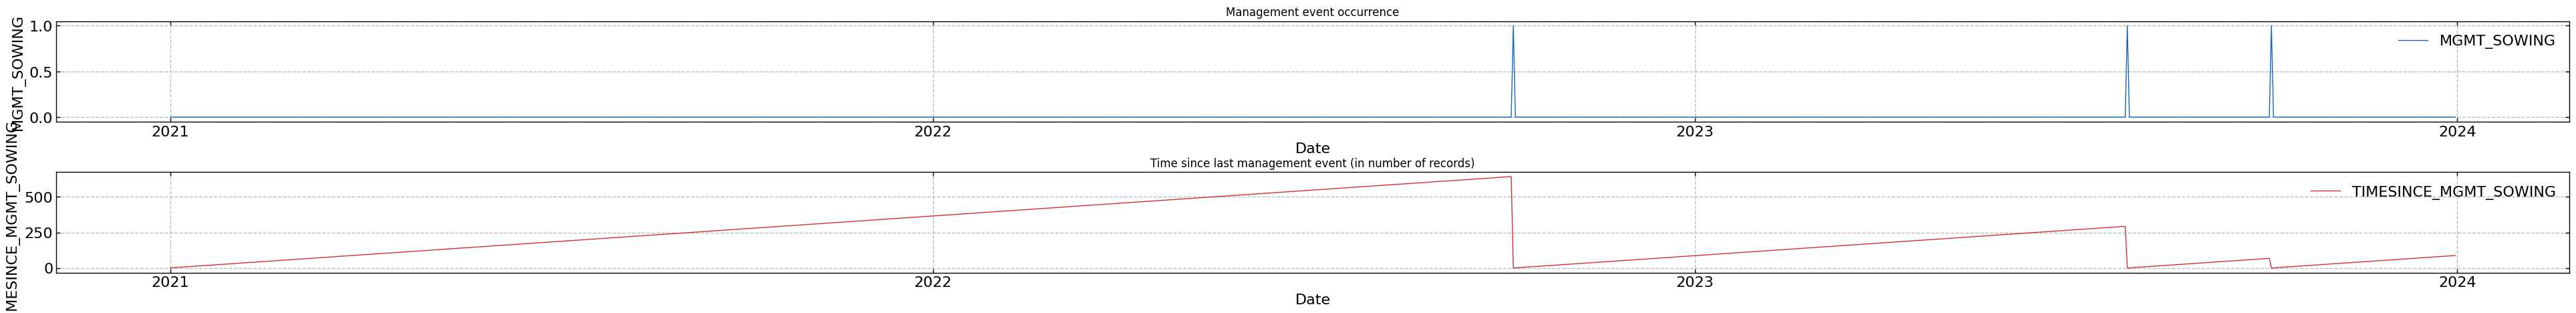

In [122]:
for v in mgmt_daily.columns:
    fig = plt.figure(facecolor='white', figsize=(40, 4), dpi=100, layout='constrained')
    gs = gridspec.GridSpec(2, 1)  # rows, cols
    gs.update(wspace=0.3, hspace=.5, left=0.03, right=0.97, top=0.97, bottom=0.03)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    TimeSeries(ax=ax1, series=mgmt_daily[v]).plot(color='#1565C0')
    TimeSeries(ax=ax2, series=timesincedf[f'TIMESINCE_{v}']).plot(color='#D32F2F')
    ax1.set_title("Management event occurrence", color='black')
    ax2.set_title("Time since last management event (in number of records)", color='black')    

## + Add `TIMESINCE` variables to management data

In [123]:
mgmt_daily = pd.concat([mgmt_daily, timesincedf], axis=1)
mgmt_daily

,MGMT_FERT_MIN,MGMT_FERT_ORG,MGMT_HARVEST,MGMT_PESTICIDE_HERBICIDE,MGMT_SOILCULTIVATION,MGMT_SOWING,TIMESINCE_MGMT_FERT_MIN,TIMESINCE_MGMT_FERT_ORG,TIMESINCE_MGMT_HARVEST,TIMESINCE_MGMT_PESTICIDE_HERBICIDE,TIMESINCE_MGMT_SOILCULTIVATION,TIMESINCE_MGMT_SOWING
2021-01-01,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-02,0,0,0,0,0,0,2,2,2,2,2,2
2021-01-03,0,0,0,0,0,0,3,3,3,3,3,3
2021-01-04,0,0,0,0,0,0,4,4,4,4,4,4
2021-01-05,0,0,0,0,0,0,5,5,5,5,5,5
2021-01-06,0,0,0,0,0,0,6,6,6,6,6,6
2021-01-07,0,0,0,0,0,0,7,7,7,7,7,7
2021-01-08,0,0,0,0,0,0,8,8,8,8,8,8
2021-01-09,0,0,0,0,0,0,9,9,9,9,9,9
2021-01-10,0,0,0,0,0,0,10,10,10,10,10,10


In [124]:
collist = mgmt_daily.columns.tolist()
collist

['MGMT_FERT_MIN',
 'MGMT_FERT_ORG',
 'MGMT_HARVEST',
 'MGMT_PESTICIDE_HERBICIDE',
 'MGMT_SOILCULTIVATION',
 'MGMT_SOWING',
 'TIMESINCE_MGMT_FERT_MIN',
 'TIMESINCE_MGMT_FERT_ORG',
 'TIMESINCE_MGMT_HARVEST',
 'TIMESINCE_MGMT_PESTICIDE_HERBICIDE',
 'TIMESINCE_MGMT_SOILCULTIVATION',
 'TIMESINCE_MGMT_SOWING']

In [125]:
mgmt_daily.to_csv("21.3_mgmt_daily.csv")

</br>

---

# **HALF-HOURLY**

---

## Half-hourly timestamp for management data

In [126]:
first_hh = pd.to_datetime(mgmt_daily.index[0]) + pd.Timedelta(minutes=15)
last_hh = pd.to_datetime(mgmt_daily.index[-1]) + pd.Timedelta(hours=23, minutes=45)
print(first_hh)
print(last_hh)

2021-01-01 00:15:00
2023-12-31 23:45:00


## Create half-hourly dataframe for management data

In [127]:
timestamp_hh = pd.date_range(first_hh, last_hh, freq='30min')
mgmt_hh = pd.DataFrame(index=timestamp_hh)
mgmt_hh['TIMESTAMP_MIDDLE'] = pd.to_datetime(mgmt_hh.index)  # For merging with daily time resolution management data
mgmt_hh['DATE'] = pd.to_datetime(mgmt_hh.index.date)  # For merging with daily time resolution management data
mgmt_hh

,TIMESTAMP_MIDDLE,DATE
2021-01-01 00:15:00,2021-01-01 00:15:00,2021-01-01
2021-01-01 00:45:00,2021-01-01 00:45:00,2021-01-01
2021-01-01 01:15:00,2021-01-01 01:15:00,2021-01-01
2021-01-01 01:45:00,2021-01-01 01:45:00,2021-01-01
2021-01-01 02:15:00,2021-01-01 02:15:00,2021-01-01
...,...,...
2023-12-31 21:45:00,2023-12-31 21:45:00,2023-12-31
2023-12-31 22:15:00,2023-12-31 22:15:00,2023-12-31
2023-12-31 22:45:00,2023-12-31 22:45:00,2023-12-31
2023-12-31 23:15:00,2023-12-31 23:15:00,2023-12-31


In [128]:
mgmt_daily['DATE'] = mgmt_daily.index
mgmt_daily['DATE'] = pd.to_datetime(mgmt_daily['DATE'])
mgmt_daily.head(3)

,MGMT_FERT_MIN,MGMT_FERT_ORG,MGMT_HARVEST,MGMT_PESTICIDE_HERBICIDE,MGMT_SOILCULTIVATION,MGMT_SOWING,TIMESINCE_MGMT_FERT_MIN,TIMESINCE_MGMT_FERT_ORG,TIMESINCE_MGMT_HARVEST,TIMESINCE_MGMT_PESTICIDE_HERBICIDE,TIMESINCE_MGMT_SOILCULTIVATION,TIMESINCE_MGMT_SOWING,DATE
2021-01-01,0,0,0,0,0,0,1,1,1,1,1,1,2021-01-01
2021-01-02,0,0,0,0,0,0,2,2,2,2,2,2,2021-01-02
2021-01-03,0,0,0,0,0,0,3,3,3,3,3,3,2021-01-03


In [129]:
# Merge on DATE column
mgmt_hh = pd.merge(mgmt_hh, mgmt_daily, on='DATE')
mgmt_hh = mgmt_hh.set_index('TIMESTAMP_MIDDLE')
mgmt_hh = mgmt_hh.drop('DATE', axis=1)
mgmt_hh

,MGMT_FERT_MIN,MGMT_FERT_ORG,MGMT_HARVEST,MGMT_PESTICIDE_HERBICIDE,MGMT_SOILCULTIVATION,MGMT_SOWING,TIMESINCE_MGMT_FERT_MIN,TIMESINCE_MGMT_FERT_ORG,TIMESINCE_MGMT_HARVEST,TIMESINCE_MGMT_PESTICIDE_HERBICIDE,TIMESINCE_MGMT_SOILCULTIVATION,TIMESINCE_MGMT_SOWING
TIMESTAMP_MIDDLE,,,,,,,,,,,,
2021-01-01 00:15:00,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-01 00:45:00,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-01 01:15:00,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-01 01:45:00,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-01 02:15:00,0,0,0,0,0,0,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:45:00,0,0,0,0,0,0,269,97,97,284,87,88
2023-12-31 22:15:00,0,0,0,0,0,0,269,97,97,284,87,88
2023-12-31 22:45:00,0,0,0,0,0,0,269,97,97,284,87,88


## List of managments in half-hourly dataframe

In [130]:
mgmt_hh_cols = mgmt_hh.columns.to_list()
mgmt_hh_cols = [sub.replace('TIMESINCE_', '') for sub in mgmt_hh_cols]
mgmt_hh_cols = list(set(mgmt_hh_cols))
mgmt_hh_cols

['MGMT_HARVEST',
 'MGMT_SOILCULTIVATION',
 'MGMT_SOWING',
 'MGMT_FERT_ORG',
 'MGMT_FERT_MIN',
 'MGMT_PESTICIDE_HERBICIDE']

In [131]:
pd.options.display.max_rows = 4000
mgmt_hh.count()

MGMT_FERT_MIN                         52560
MGMT_FERT_ORG                         52560
MGMT_HARVEST                          52560
MGMT_PESTICIDE_HERBICIDE              52560
MGMT_SOILCULTIVATION                  52560
MGMT_SOWING                           52560
TIMESINCE_MGMT_FERT_MIN               52560
TIMESINCE_MGMT_FERT_ORG               52560
TIMESINCE_MGMT_HARVEST                52560
TIMESINCE_MGMT_PESTICIDE_HERBICIDE    52560
TIMESINCE_MGMT_SOILCULTIVATION        52560
TIMESINCE_MGMT_SOWING                 52560
dtype: int64

In [132]:
pd.options.display.max_rows = 4000
mgmt_hh.isnull().sum()

MGMT_FERT_MIN                         0
MGMT_FERT_ORG                         0
MGMT_HARVEST                          0
MGMT_PESTICIDE_HERBICIDE              0
MGMT_SOILCULTIVATION                  0
MGMT_SOWING                           0
TIMESINCE_MGMT_FERT_MIN               0
TIMESINCE_MGMT_FERT_ORG               0
TIMESINCE_MGMT_HARVEST                0
TIMESINCE_MGMT_PESTICIDE_HERBICIDE    0
TIMESINCE_MGMT_SOILCULTIVATION        0
TIMESINCE_MGMT_SOWING                 0
dtype: int64

## Final half-hourly management dataframe

In [133]:
# Sort columns
mgmt_hh = mgmt_hh.reindex(sorted(mgmt_hh.columns), axis=1)

In [134]:
mgmt_hh

,MGMT_FERT_MIN,MGMT_FERT_ORG,MGMT_HARVEST,MGMT_PESTICIDE_HERBICIDE,MGMT_SOILCULTIVATION,MGMT_SOWING,TIMESINCE_MGMT_FERT_MIN,TIMESINCE_MGMT_FERT_ORG,TIMESINCE_MGMT_HARVEST,TIMESINCE_MGMT_PESTICIDE_HERBICIDE,TIMESINCE_MGMT_SOILCULTIVATION,TIMESINCE_MGMT_SOWING
TIMESTAMP_MIDDLE,,,,,,,,,,,,
2021-01-01 00:15:00,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-01 00:45:00,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-01 01:15:00,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-01 01:45:00,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-01 02:15:00,0,0,0,0,0,0,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:45:00,0,0,0,0,0,0,269,97,97,284,87,88
2023-12-31 22:15:00,0,0,0,0,0,0,269,97,97,284,87,88
2023-12-31 22:45:00,0,0,0,0,0,0,269,97,97,284,87,88


In [135]:
[print(c) for c in mgmt_hh];

MGMT_FERT_MIN
MGMT_FERT_ORG
MGMT_HARVEST
MGMT_PESTICIDE_HERBICIDE
MGMT_SOILCULTIVATION
MGMT_SOWING
TIMESINCE_MGMT_FERT_MIN
TIMESINCE_MGMT_FERT_ORG
TIMESINCE_MGMT_HARVEST
TIMESINCE_MGMT_PESTICIDE_HERBICIDE
TIMESINCE_MGMT_SOILCULTIVATION
TIMESINCE_MGMT_SOWING


## Plot (example one month)

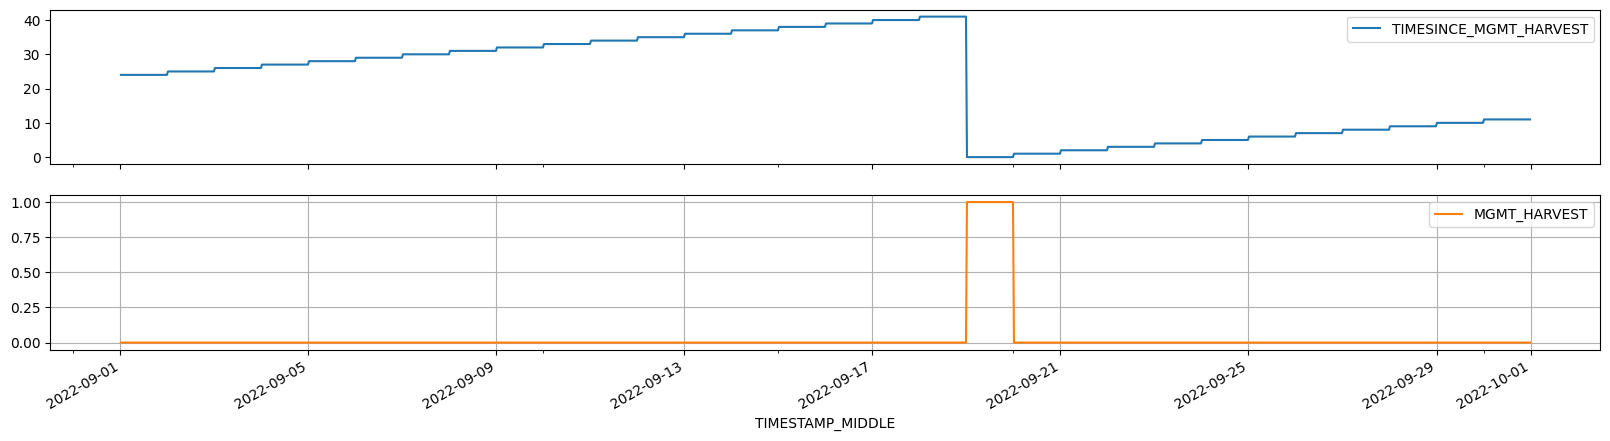

In [136]:
locs = (mgmt_hh.index.year == 2022) & (mgmt_hh.index.month == 9)
mgmt_hh.loc[locs, ['TIMESINCE_MGMT_HARVEST', 'MGMT_HARVEST']].plot(x_compat=True, subplots=True, figsize=(20, 5))
plt.grid();

## Plot complete management dataframe

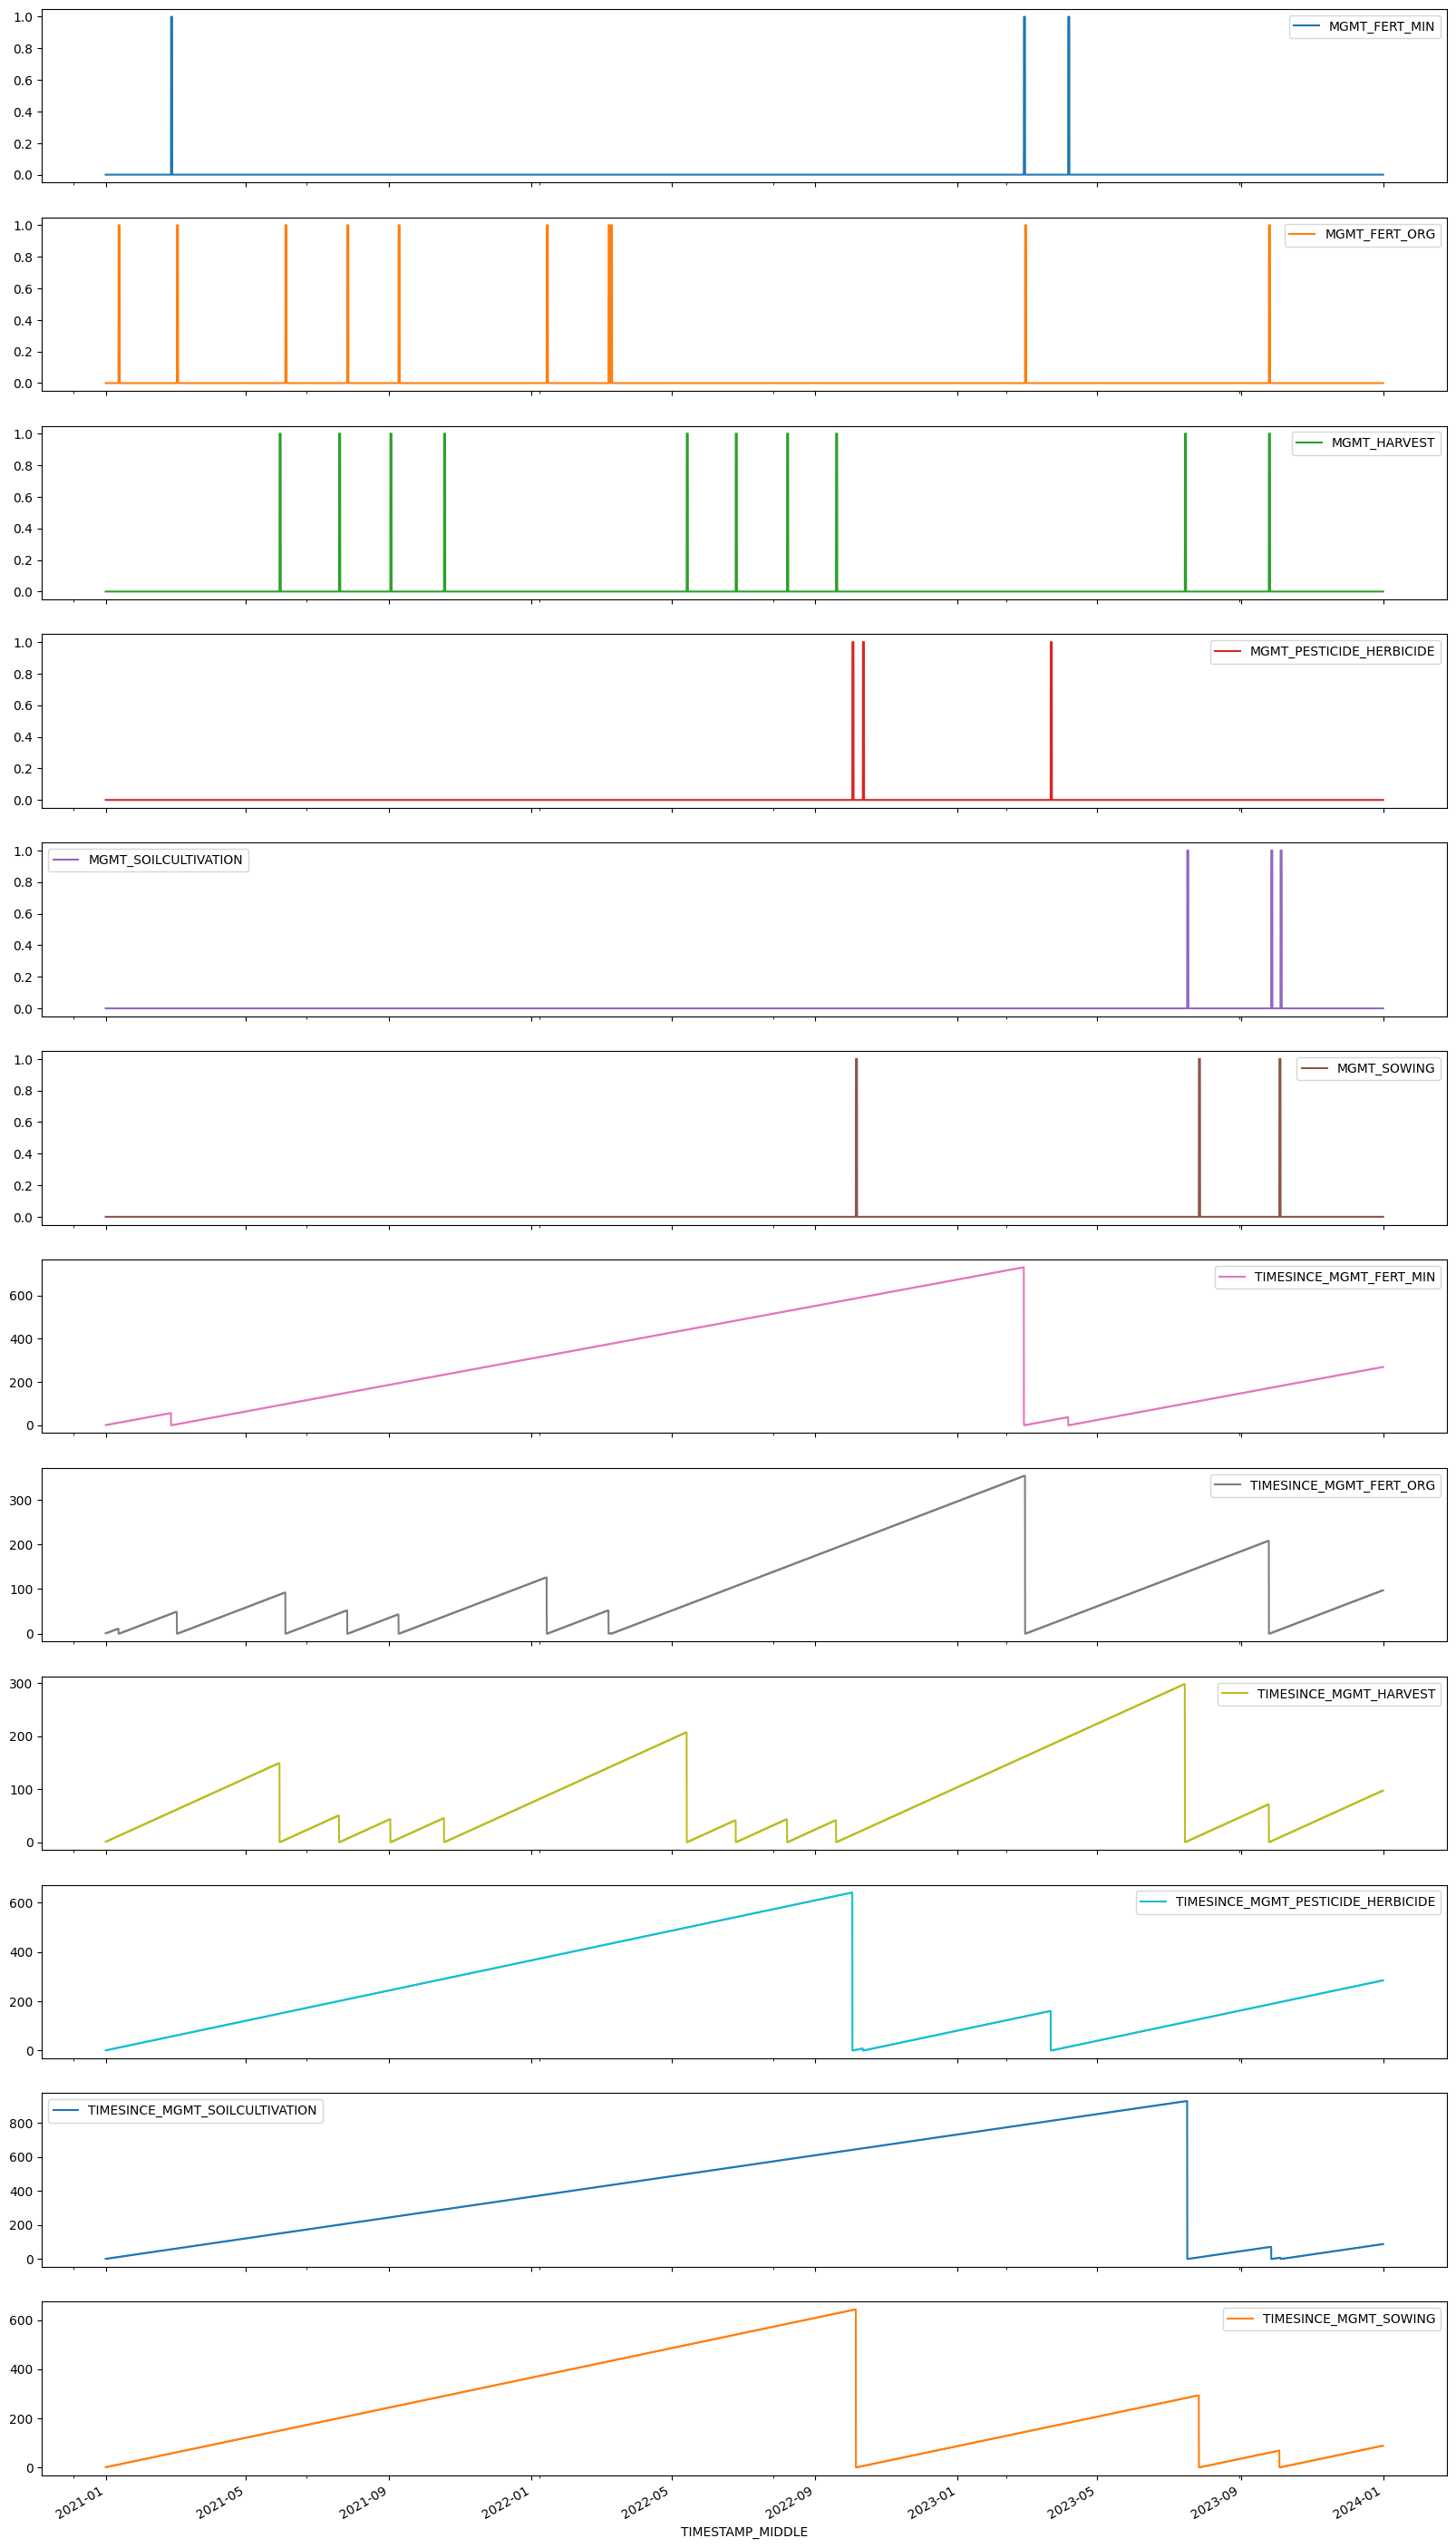

In [137]:
plt.rcParams["figure.dpi"] = 100
mgmt_hh.plot(x_compat=True, subplots=True, figsize=(20, 40));

</br>

---

# Export data to file

---

## Keep management info from 2021 onwards

In [138]:
keeplocs = (mgmt_hh.index.year >= 2021) & (mgmt_hh.index.year <= 2023)
mgmt_hh = mgmt_hh.loc[keeplocs].copy()
mgmt_hh

,MGMT_FERT_MIN,MGMT_FERT_ORG,MGMT_HARVEST,MGMT_PESTICIDE_HERBICIDE,MGMT_SOILCULTIVATION,MGMT_SOWING,TIMESINCE_MGMT_FERT_MIN,TIMESINCE_MGMT_FERT_ORG,TIMESINCE_MGMT_HARVEST,TIMESINCE_MGMT_PESTICIDE_HERBICIDE,TIMESINCE_MGMT_SOILCULTIVATION,TIMESINCE_MGMT_SOWING
TIMESTAMP_MIDDLE,,,,,,,,,,,,
2021-01-01 00:15:00,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-01 00:45:00,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-01 01:15:00,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-01 01:45:00,0,0,0,0,0,0,1,1,1,1,1,1
2021-01-01 02:15:00,0,0,0,0,0,0,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:45:00,0,0,0,0,0,0,269,97,97,284,87,88
2023-12-31 22:15:00,0,0,0,0,0,0,269,97,97,284,87,88
2023-12-31 22:45:00,0,0,0,0,0,0,269,97,97,284,87,88


## Save to file

In [139]:
mgmt_hh.to_csv("21.4_mgmt_full_timestamp.csv")